# Import Libraries

In [283]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skModel

# Importing Data

In [284]:
#importing dataset
dataset = pd.read_csv('Loan Eligibility Prediction.csv')
df = dataset.copy()
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


# Cleaning and Preparation
Checking the quality of the data by looking mainly at the correctness, completeness, and redundancy within the dataset. 

In [285]:
#Completeness (Checking missing values)
print(df.isnull().sum()) 

#Redundancy (Dropping duplicate values)
print(df.duplicated())

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64
0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool


# Data Exploration

In [286]:
print(df.shape)
print(df.info())
print(df.columns)
print(df.describe())

(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB
None
Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self

# Data Transfomration
To aid in the analysis I am changing all categorical data to boolean.

In [ ]:
#Data Transformation
df['Married'].replace({'Yes':1, 'No':0}, inplace=True)
df['Education'].replace({'Graduate':1, 'Not Graduate':0}, inplace=True)
df['Self_Employed'].replace({'Yes':1, 'No':0}, inplace=True)
df['Property_Area'].replace({'Urban':2, 'Semiurban':1, 'Rural':0}, inplace=True)
df['Loan_Status'].replace({'Y':1, 'N':0}, inplace=True)
df['Gender'].replace({'Male':1, 'Female':0}, inplace=True)

df.drop('Customer_ID', axis=1, inplace=True)
df.drop(['Gender'], axis=1, inplace=True)
df.info()

# Feature Engineering
I created the column of combined income that combines the applicant's income and the coapplicant's income

In [288]:
combinedIncome = []
for i in range(len(df)):
    combinedIncome.append(df.iloc[i]['Applicant_Income'] + df.iloc[i]['Coapplicant_Income'])

df['Combined_Income'] = combinedIncome
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Married             614 non-null    int64  
 1   Dependents          614 non-null    int64  
 2   Education           614 non-null    int64  
 3   Self_Employed       614 non-null    int64  
 4   Applicant_Income    614 non-null    int64  
 5   Coapplicant_Income  614 non-null    float64
 6   Loan_Amount         614 non-null    int64  
 7   Loan_Amount_Term    614 non-null    int64  
 8   Credit_History      614 non-null    int64  
 9   Property_Area       614 non-null    int64  
 10  Loan_Status         614 non-null    int64  
 11  Combined_Income     614 non-null    float64
dtypes: float64(2), int64(10)
memory usage: 57.7 KB


   Income_Range  Number_of_Applicants  Percentage
0             1                     1    0.162866
1             2                    26    4.234528
2             3                    70   11.400651
3             4                    84   13.680782
4             5                    75   12.214984
5             6                    48    7.817590
6             7                    28    4.560261
[1, 26, 70, 84, 75, 48, 28]
3620.0


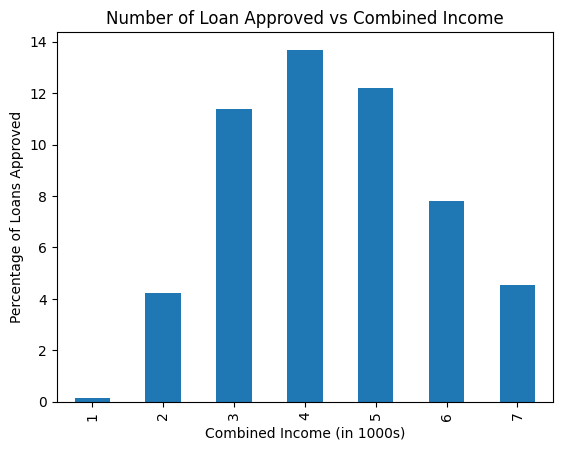

In [289]:
#Data analysis and visualization
labels = list(range(1, 8))
values = [0,0,0,0,0,0,0]
percentages = [0.0, 0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0]
for i in range(0, len(df)):
    if df['Combined_Income'][i] <= 2000 and df['Loan_Status'][i] == 1:
        values[0] += 1
    elif 2000 < df['Combined_Income'][i] <= 3000 and df['Loan_Status'][i] == 1:
        values[1] += 1
    elif 3000 < df['Combined_Income'][i] <= 4000 and df['Loan_Status'][i] == 1:
        values[2] += 1
    elif 4000 < df['Combined_Income'][i] <= 5000 and df['Loan_Status'][i] == 1:
        values[3] += 1
    elif 5000 < df['Combined_Income'][i] <= 6000 and df['Loan_Status'][i] == 1:
        values[4] += 1
    elif 6000 < df['Combined_Income'][i] <= 7000 and df['Loan_Status'][i] == 1:
        values[5] += 1
    elif 7000 < df['Combined_Income'][i] <= 8000 and df['Loan_Status'][i] == 1:
        values[6] += 1

for i in range(0, len(values)):
    percentages[i] = (values[i] / len(df)) * 100

new_df = pd.DataFrame({'Income_Range': labels, 'Number_of_Applicants': values, 'Percentage': percentages})
print(new_df)
new_df.plot(x='Income_Range', y='Percentage', kind='bar', legend=False)

print(values)
print(df['Combined_Income'][2])

plt.title('Number of Loan Approved vs Combined Income')
plt.xlabel('Combined Income (in 1000s)')
plt.ylabel('Percentage of Loans Approved')
plt.show()

In [290]:
lables = df.columns
print(lables)
df = df[[c for c in df.columns if c != 'Loan_Status'] + ['Loan_Status']]
df.columns

Index(['Married', 'Dependents', 'Education', 'Self_Employed',
       'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Combined_Income'],
      dtype='object')


Index(['Married', 'Dependents', 'Education', 'Self_Employed',
       'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Combined_Income', 'Loan_Status'],
      dtype='object')

# Feature Selection
## Scatter Matrix

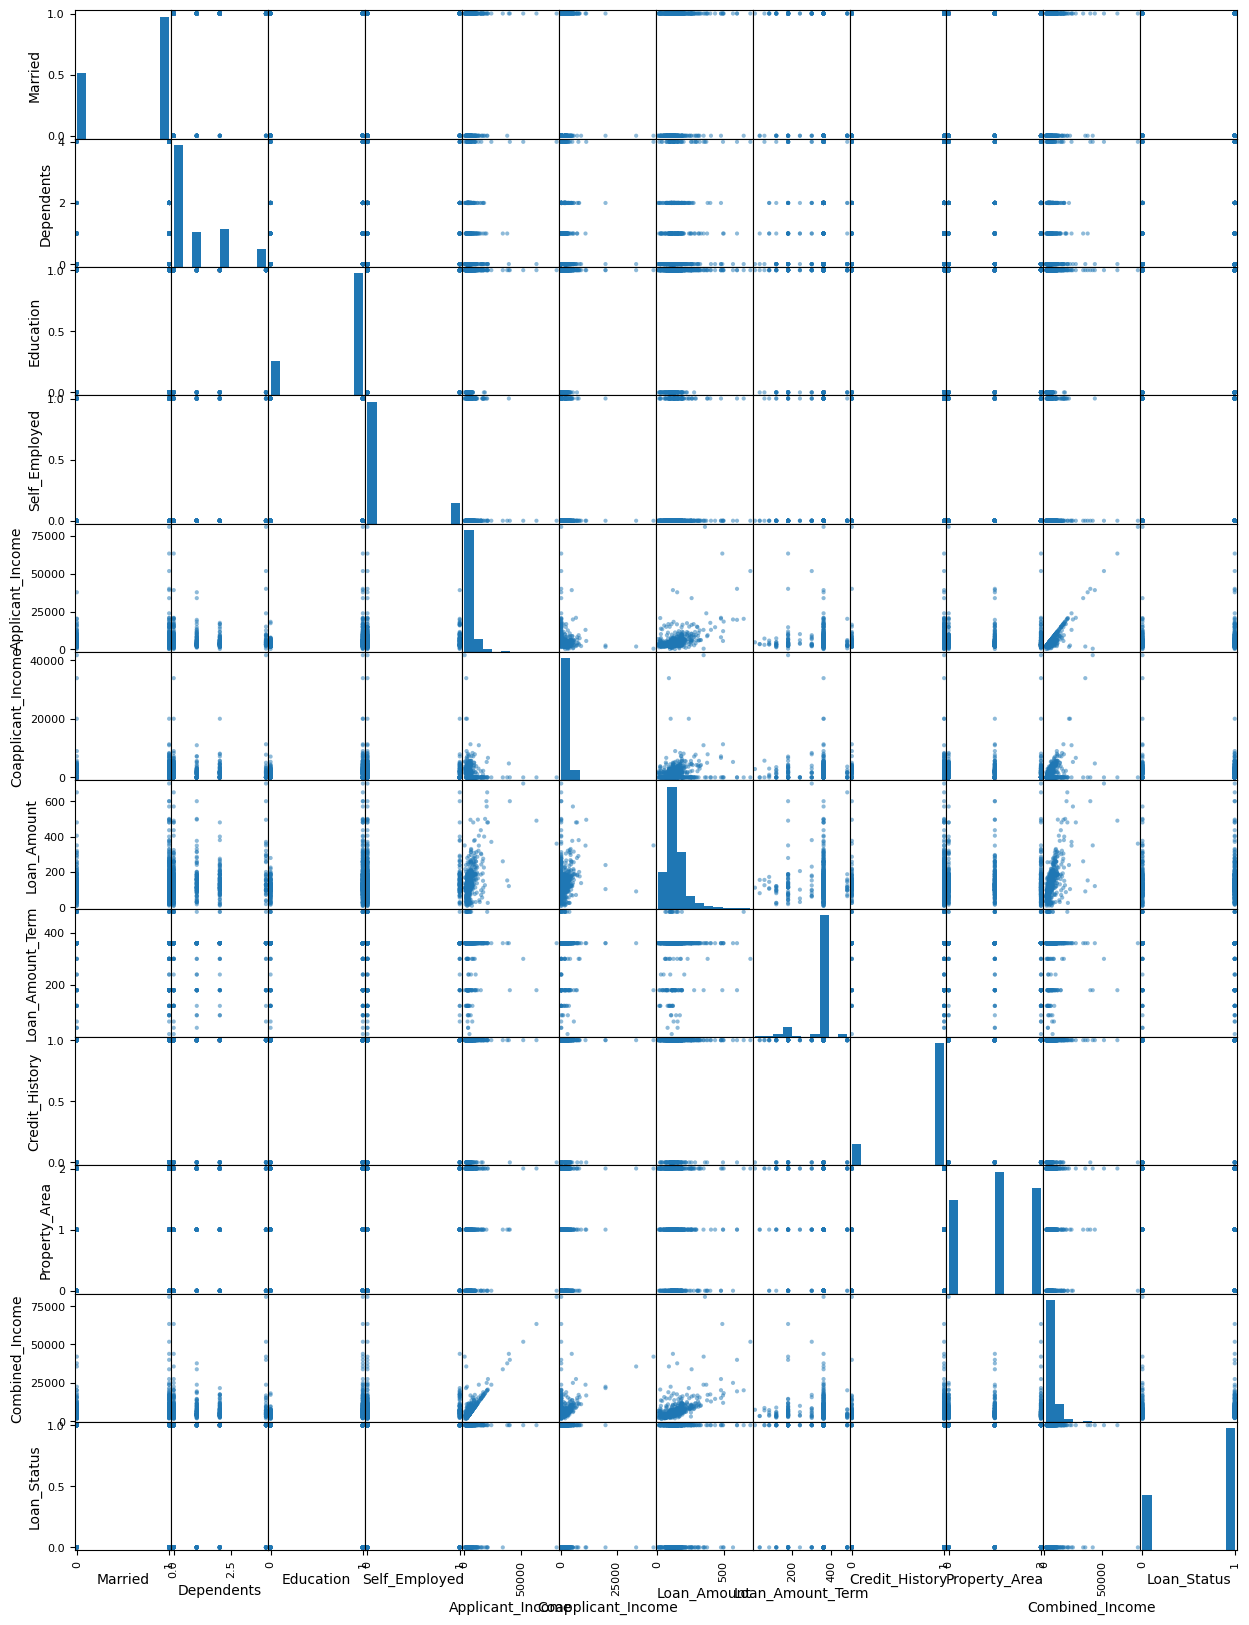

In [291]:
#relationship analysis
pd.plotting.scatter_matrix(df, figsize=(15, 20)) #we use the corr matrix to identify relationships between variables
plt.show()

## Variance Threshhold

In [292]:
import sklearn.feature_selection._variance_threshold as skVT
selector = skVT.VarianceThreshold(threshold=1)
selector.fit(df.drop('Loan_Status', axis=1), df['Loan_Status'])
features = selector.get_support(indices = True)
selector.variances_

array([2.27548833e-01, 1.47783000e+00, 1.70611890e-01, 1.26242719e-01,
       3.72596078e+07, 8.54898338e+06, 7.57111349e+03, 4.85245424e+03,
       1.27385967e-01, 6.19117975e-01, 4.16464004e+07])

## Mutual Infromation

In [293]:
import sklearn.feature_selection._mutual_info as skMI
mi = skMI.mutual_info_classif(df.drop(['Loan_Status'], axis=1), df['Loan_Status'])
mi

array([0.        , 0.02772313, 0.        , 0.00216071, 0.0057808 ,
       0.02313398, 0.        , 0.01121169, 0.14931487, 0.02196324,
       0.        ])

## Correlation Matrix 

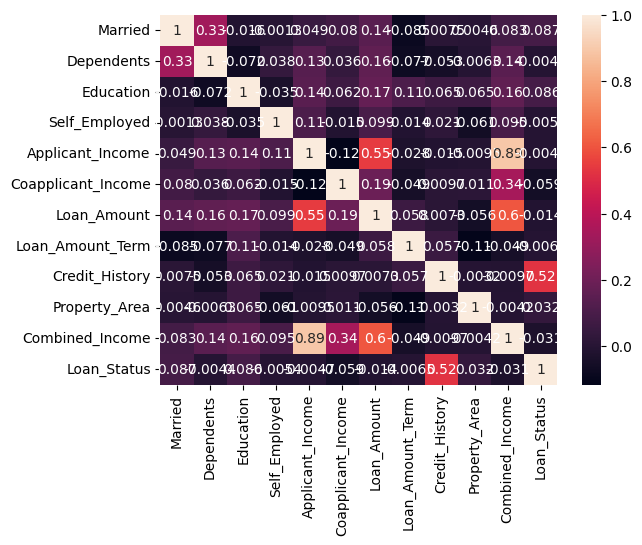

In [294]:
#heatmap gives us a better visual representation of correlation
correlation = df.corr()
sns.heatmap(correlation, annot=True) 
plt.show()

## Selected Features

In [295]:
type(features)
for i in features:
    print(i)

1
4
5
6
7
10


In [296]:
selected_features = []
for i in features:
    selected_features.append(df.columns[i])

df = df[selected_features + ['Loan_Status']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Dependents          614 non-null    int64  
 1   Applicant_Income    614 non-null    int64  
 2   Coapplicant_Income  614 non-null    float64
 3   Loan_Amount         614 non-null    int64  
 4   Loan_Amount_Term    614 non-null    int64  
 5   Combined_Income     614 non-null    float64
 6   Loan_Status         614 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 33.7 KB


# Model Building
I have decided to use the K Nearest Neighbours Model and the Decision Tree

In [297]:
#Data Modeling
from sklearn.model_selection import train_test_split
X = df.drop('Loan_Status', axis=1)
Y = df['Loan_Status']

In [298]:
X.shape, Y.shape

((614, 6), (614,))

In [299]:
#Split DataSet
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

## KNN

In [300]:
from sklearn.neighbors import KNeighborsClassifier as KNN
model = KNN(n_neighbors=11)
model.fit(X_train, Y_train)
predict = model.predict(X_test)
model.score(X_test, Y_test)
print('Model Accuracy:', model.score(X_test, Y_test)*100)

Model Accuracy: 74.79674796747967


In [301]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, predict) 
print('confusion matrix:')
cm

confusion matrix:


array([[ 9, 26],
       [ 5, 83]])

In [302]:
from sklearn.metrics import classification_report
cr = classification_report(Y_test, predict)
print(cr)

              precision    recall  f1-score   support

           0       0.64      0.26      0.37        35
           1       0.76      0.94      0.84        88

    accuracy                           0.75       123
   macro avg       0.70      0.60      0.60       123
weighted avg       0.73      0.75      0.71       123



## Decision Tree

In [303]:
from sklearn.tree import DecisionTreeClassifier
modelDT = DecisionTreeClassifier()
modelDT.fit(X_train, Y_train)
DT_predict = modelDT.predict(X_test)
print('Accuracy Score: ' , modelDT.score(X_test, Y_test)*100)

Accuracy Score:  60.97560975609756


In [304]:
print('Confusion Matrix: ') 
confusion_matrix(Y_test, DT_predict)

Confusion Matrix: 


array([[16, 19],
       [29, 59]])

In [305]:
print(classification_report(Y_test, DT_predict))

              precision    recall  f1-score   support

           0       0.36      0.46      0.40        35
           1       0.76      0.67      0.71        88

    accuracy                           0.61       123
   macro avg       0.56      0.56      0.56       123
weighted avg       0.64      0.61      0.62       123

